# Task 1 — Reproducing the official baseline

Goal (Act 1): recompute the three indicators of `baseline_officielle.csv` from the raw data, following the
definitions of `docs/notice_metier.md`, and understand any gap before moving on.

Rules applied (from the guide, not free choices):
- **Response time** = alert → arrival of the **first vehicle to arrive**, whatever its type.
- **Unfulfilled** intervention (empty arrival time) → conventional delay of **60 min**, kept in the delay indicators.
- **Compliance** = delay ≤ threshold(zone, reason); **Z4 has no binding target** and is excluded from the rate.

Raw files live in `raw_data/` (byte-identical copy of `donnees/`, never modified). Shared code is in `helpers.py`.

In [1]:
import pandas as pd
import numpy as np
import helpers as h

pd.set_option("display.width", 160)
raw = h.load_raw()
pd.DataFrame({name: df.shape for name, df in raw.items()}, index=["rows", "columns"]).T

,rows,columns
interventions,74215,9
communes,120,5
centres,30,6
plan_deploiement,960,3
seuils_reglementaires,12,3
baseline_officielle,3,2


## 1. Brief inspection — only what the calculation needs

In [2]:
iv = raw["interventions"]
print("vehicle rows:", len(iv), "| interventions:", iv["id_intervention"].nunique())
print("vehicles per intervention:", iv.groupby("id_intervention").size().value_counts().sort_index().to_dict())
print("exact duplicate rows:", iv.duplicated().sum())

# One intervention = one alert, one commune, one reason?
g = iv.groupby("id_intervention")
print("ids with >1 alert time / commune / reason:",
      (g["horodatage_alerte"].nunique() > 1).sum(), (g["insee"].nunique() > 1).sum(), (g["raison"].nunique() > 1).sum())
pd.crosstab(iv["raison"], iv["type_engin"], margins=True)

vehicle rows: 74215 | interventions: 55000
vehicles per intervention: {1: 42204, 2: 6377, 3: 6419}
exact duplicate rows: 0
ids with >1 alert time / commune / reason: 0 0 0


type_engin,CCR,FPT,VSAV,VTU,All
raison,,,,,
AVP,855,841,7390,861,9947
INC,1933,11981,1978,2028,17920
SAP,1880,1966,40501,2001,46348
All,4668,14788,49869,4890,74215


**Missing arrivals.** The guide says an unfulfilled intervention appears with an empty arrival time.
Check that these rows are whole interventions (no other vehicle arrived) and see their reasons.

In [3]:
missing = iv[iv["horodatage_arrivee"].isna()]
ids_missing = missing["id_intervention"].unique()
other_rows = iv[iv["id_intervention"].isin(ids_missing) & iv["horodatage_arrivee"].notna()]
print("rows with empty arrival:", len(missing), "| interventions concerned:", len(ids_missing),
      "| of which a vehicle still arrived:", other_rows["id_intervention"].nunique())
missing.groupby(["raison", "type_engin"]).size().rename("unfulfilled interventions")

rows with empty arrival: 672 | interventions concerned: 672 | of which a vehicle still arrived: 0


raison  type_engin
AVP     VSAV           60
INC     FPT           290
SAP     VSAV          322
Name: unfulfilled interventions, dtype: int64

**No dispatch-rank column.** The guide mentions a rank, but the file has none, and the file order is not
the arrival order (example below: the VTU is listed first, the FPT arrives first). So the first vehicle must be found
by **earliest arrival time**, not by row order.

In [4]:
iv[iv["id_intervention"] == "I000003"]

,id_intervention,horodatage_alerte,insee,raison,type_engin,code_cis,delai_depart_min,duree_trajet_s,horodatage_arrivee
3,I000003,2025-01-01 01:16:58,25001,INC,VTU,CIS23,3.54,1290.0,2025-01-01 01:42:00
4,I000003,2025-01-01 01:16:58,25001,INC,FPT,CIS07,1.67,526.0,2025-01-01 01:27:24


In [5]:
# Is the earliest-arriving vehicle ever something other than VSAV / FPT? (guide: other types never respond first)
arrived = iv.dropna(subset=["horodatage_arrivee"])
first_rows = arrived.sort_values("horodatage_arrivee").drop_duplicates("id_intervention")
first_rows["type_engin"].value_counts()

type_engin
VSAV    44644
FPT      9684
Name: count, dtype: int64

In [6]:
# Timestamps vs duration columns: arrival - alert should equal delai_depart_min + duree_trajet_s / 60
ts = (arrived["horodatage_arrivee"] - arrived["horodatage_alerte"]).dt.total_seconds()
dur = arrived["delai_depart_min"] * 60 + arrived["duree_trajet_s"]
print(f"max |timestamps - durations| = {(ts - dur).abs().max():.1f} s  (timestamps are rounded to the second)")
raw["seuils_reglementaires"].pivot(index="zone_sdacr", columns="raison", values="seuil_min")

max |timestamps - durations| = 1.6 s  (timestamps are rounded to the second)


raison,AVP,INC,SAP
zone_sdacr,,,
Z1,40.0,20.0,20.0
Z2,40.0,25.0,20.0
Z3,40.0,30.0,20.0
Z4,NaN,NaN,NaN


Inspection summary:
- 74 215 vehicle rows for 55 000 interventions; no exact duplicate rows; each id has a single alert, commune and reason.
- 672 interventions have an empty arrival, each is a single row with no other vehicle → these are the unfulfilled ones.
- No rank column and row order ≠ arrival order → first vehicle = earliest arrival.
- Only VSAV and FPT ever arrive first, as the guide states, so keeping all vehicle types changes nothing.
- Timestamps and duration columns agree to within 1.6 s (rounding). Z4 thresholds are empty (no binding target).

## 2. One row per intervention, judged on its first-arriving vehicle

In [7]:
interventions = h.build_interventions(raw)          # delay = arrival timestamp - alert timestamp
h.DATA.mkdir(exist_ok=True)
interventions.to_csv(h.DATA / "first_arrivals.csv", index=False)
print(interventions.shape)
interventions.head()

(55000, 13)


,id_intervention,alert_time,insee,reason,n_vehicles,first_vehicle,first_centre,observed_delay_min,unfulfilled,delay_min,zone,threshold_min,compliant
0,I000000,2025-01-01 00:28:20,25106,SAP,1,VSAV,CIS07,6.250000,False,6.250000,Z2,20.0,True
1,I000001,2025-01-01 00:30:36,25082,SAP,1,VSAV,CIS27,3.983333,False,3.983333,Z1,20.0,True
2,I000002,2025-01-01 00:40:08,25021,SAP,1,VSAV,CIS23,13.366667,False,13.366667,Z2,20.0,True
3,I000003,2025-01-01 01:16:58,25001,INC,2,FPT,CIS07,10.433333,False,10.433333,Z2,25.0,True
4,I000004,2025-01-01 01:29:08,25007,SAP,1,VSAV,CIS22,5.366667,False,5.366667,Z2,20.0,True


## 3. The three indicators vs the official baseline

In [8]:
kpis = h.compute_kpis(interventions)
check = h.compare_to_baseline(kpis, raw["baseline_officielle"])
h.RESULTS.mkdir(exist_ok=True)
check.round(4).to_csv(h.RESULTS / "kpi_check.csv")
check.round(4)

,official,recomputed,gap
indicator,,,
p90_delai_sap_min,25.51,25.5100,-0.0000
inc_non_honorees,290.00,290.0000,0.0000
taux_conformite_pct,86.45,86.4605,0.0105


## 4. Where does the 0.01-point compliance gap come from?

`p90_delai_sap_min` and `inc_non_honorees` match exactly. The compliance rate is 86.46 % against 86.45 %
(≈ 5 interventions out of 53 525). Same calculation, but with the delay taken from the duration columns
(`delai_depart_min + duree_trajet_s / 60`, precise to a fraction of a second) instead of the timestamps:

In [9]:
interventions_dur = h.build_interventions(raw, delay_source="durations")
check_dur = h.compare_to_baseline(h.compute_kpis(interventions_dur), raw["baseline_officielle"])
pd.concat({"timestamps": check["recomputed"], "durations": check_dur["recomputed"],
           "official": check["official"]}, axis=1).round(4)

,timestamps,durations,official
indicator,,,
p90_delai_sap_min,25.5100,25.5033,25.51
inc_non_honorees,290.0000,290.0000,290.00
taux_conformite_pct,86.4605,86.4512,86.45


In [10]:
# Interventions whose compliance verdict depends on the delay source
both = interventions.set_index("id_intervention")[["reason", "zone", "threshold_min", "delay_min"]].join(
    interventions_dur.set_index("id_intervention")["delay_min"].rename("delay_min_durations"))
flips = both[both["threshold_min"].notna()
             & ((both["delay_min"] <= both["threshold_min"]) != (both["delay_min_durations"] <= both["threshold_min"]))]
flips.assign(delay_s=flips["delay_min"] * 60, delay_s_durations=flips["delay_min_durations"] * 60).round(2)

,reason,zone,threshold_min,delay_min,delay_min_durations,delay_s,delay_s_durations
id_intervention,,,,,,,
I021374,INC,Z2,25.0,25.00,25.00,1500.0,1500.2
I022955,SAP,Z2,20.0,20.00,20.01,1200.0,1200.6
I030359,SAP,Z2,20.0,20.00,20.01,1200.0,1200.4
I040745,SAP,Z3,20.0,20.00,20.01,1200.0,1200.6
I045773,INC,Z3,30.0,30.02,30.00,1801.0,1800.0
I047452,SAP,Z2,20.0,20.00,20.01,1200.0,1200.4
I052951,INC,Z2,25.0,25.00,25.01,1500.0,1500.8


Reading of the gap:
- 7 interventions are **within one second of their threshold**. Six are exactly on it when rounded to the second
  (so compliant), but 0.2–0.8 s over it in the duration columns; one is 1 s over in the timestamps but exactly on it
  in the durations. Net: 5 fewer compliant interventions with the durations.
- With the duration columns the compliance rate is **86.45 % (exact)**, but the SAP P90 becomes 25.50 instead of 25.51.
- So neither precision reproduces all three to the last digit; each residual is a **sub-second rounding effect**
  (≤ 0.01 point, ≤ 0.4 s), which the brief calls a negligible gap. The calculation itself (first arrival, 60-min
  convention, Z4 exclusion, zone × reason thresholds) is confirmed.
- Kept as reference: **timestamps**, the guide's literal definition (alert → arrival), which reproduces P90 and the
  unfulfilled-fire count exactly.

## 5. Where and when coverage deteriorates — three figures for officers

All three use the reference calculation above (first arrival, 60-min convention). "Late" = above the regulatory
threshold of the zone and reason; Z4 has no target and is shown apart.

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE, ORANGE, AQUA, NO_TARGET = "#2a78d6", "#eb6834", "#1baf7a", "#c9c8c3"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
FIG = h.RESULTS

centres = raw["centres"]
communes = raw["communes"]
judged = interventions[interventions["compliant"].notna()].assign(late=lambda d: ~d["compliant"].astype(bool))

### Figure 1 — Where: share of late arrivals by commune

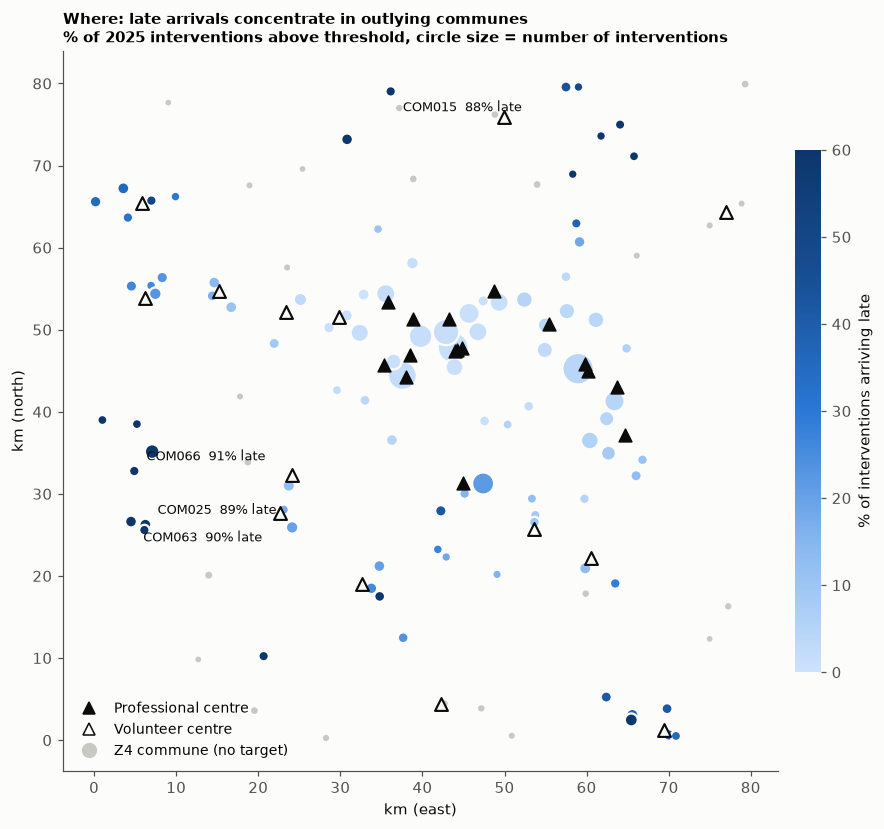

In [12]:
by_commune = (interventions.groupby("insee").size().rename("n").to_frame()
              .join(judged.groupby("insee")["late"].mean().mul(100).rename("late_pct"))
              .join(communes.set_index("insee")[["nom_commune", "x_km", "y_km", "zone_sdacr"]]))
size = 25 + 400 * by_commune["n"] / by_commune["n"].max()
ramp = LinearSegmentedColormap.from_list("blue", ["#cde2fb", "#86b6ef", "#2a78d6", "#184f95", "#0d366b"])

fig, ax = plt.subplots(figsize=(8.6, 7.6))
z4 = by_commune["zone_sdacr"] == "Z4"
ax.scatter(by_commune.loc[z4, "x_km"], by_commune.loc[z4, "y_km"], s=size[z4], color=NO_TARGET,
           edgecolor=SURFACE, linewidth=1.5, zorder=2)
pts = ax.scatter(by_commune.loc[~z4, "x_km"], by_commune.loc[~z4, "y_km"], s=size[~z4],
                 c=by_commune.loc[~z4, "late_pct"], cmap=ramp, vmin=0, vmax=60,
                 edgecolor=SURFACE, linewidth=1.5, zorder=3)
pro = centres["regime"] == "professionnel"
ax.scatter(centres.loc[pro, "x_km"], centres.loc[pro, "y_km"], marker="^", s=70, color=INK, zorder=4)
ax.scatter(centres.loc[~pro, "x_km"], centres.loc[~pro, "y_km"], marker="^", s=70, facecolor=SURFACE,
           edgecolor=INK, linewidth=1.4, zorder=4)
worst = by_commune.loc[~z4].nlargest(4, "late_pct")
for i, (_, row) in enumerate(worst.iterrows()):
    ax.annotate(f"{row['nom_commune']}  {row['late_pct']:.0f}% late", (row["x_km"], row["y_km"]),
                xytext=(8, 7 if i % 2 == 0 else -13), textcoords="offset points", fontsize=8.5, color=INK, zorder=5)
cb = fig.colorbar(pts, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("% of interventions arriving late", color=INK)
cb.outline.set_visible(False)
ax.legend(handles=[
    Line2D([], [], marker="^", ls="", color=INK, ms=8, label="Professional centre"),
    Line2D([], [], marker="^", ls="", mfc=SURFACE, mec=INK, ms=8, label="Volunteer centre"),
    Line2D([], [], marker="o", ls="", color=NO_TARGET, ms=9, label="Z4 commune (no target)"),
], loc="lower left", frameon=False, fontsize=9)
ax.set_title("Where: late arrivals concentrate in outlying communes\n"
             "% of 2025 interventions above threshold, circle size = number of interventions",
             loc="left", fontsize=10)
ax.set_xlabel("km (east)"); ax.set_ylabel("km (north)"); ax.set_aspect("equal"); ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "map_late_share.png")
plt.show()

### Figure 2 — When (time of day): punctuality by hour, by type of first centre

Communes are grouped by the regime of their first centre in the plan (professional or volunteer).

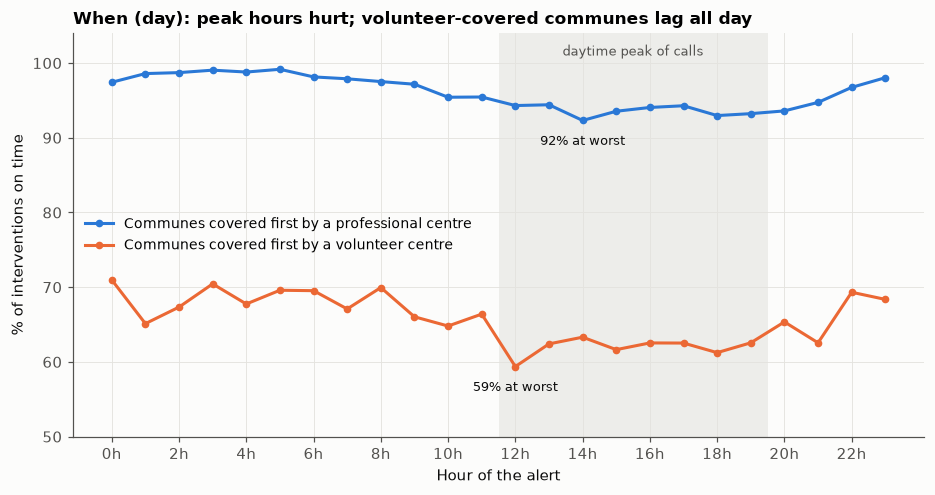

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
regime,,,,,,,,,,,,,,,,,,,,,
professionnel,97.4,98.6,98.7,99.0,98.8,99.2,98.1,97.9,97.5,97.2,...,92.3,93.5,94.1,94.3,93.0,93.2,93.6,94.7,96.7,98.0
volontaire,71.0,65.1,67.3,70.4,67.8,69.6,69.5,67.1,70.0,66.0,...,63.3,61.6,62.5,62.5,61.2,62.6,65.4,62.6,69.3,68.4


In [13]:
regime_first = raw["plan_deploiement"].query("rang == 1").set_index("insee")["code_cis"].map(
    centres.set_index("code_cis")["regime"])
hourly = (judged.assign(hour=judged["alert_time"].dt.hour, regime=judged["insee"].map(regime_first))
          .groupby(["regime", "hour"])["compliant"].apply(lambda s: 100 * s.astype(bool).mean()).unstack(0))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for col, color, label in [("professionnel", BLUE, "Communes covered first by a professional centre"),
                          ("volontaire", ORANGE, "Communes covered first by a volunteer centre")]:
    ax.plot(hourly.index, hourly[col], color=color, lw=2, marker="o", ms=4, label=label)
    ax.annotate(f"{hourly[col].min():.0f}% at worst", (hourly[col].idxmin(), hourly[col].min()),
                xytext=(0, -16), textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.axvspan(11.5, 19.5, color=GRID, alpha=0.6, lw=0, zorder=0)
ax.text(15.5, 101, "daytime peak of calls", ha="center", fontsize=8.5, color=MUTED)
ax.set_xticks(range(0, 24, 2), [f"{hh}h" for hh in range(0, 24, 2)])
ax.set_ylim(50, 104); ax.set_ylabel("% of interventions on time"); ax.set_xlabel("Hour of the alert")
ax.set_title("When (day): peak hours hurt; volunteer-covered communes lag all day", fontsize=11)
ax.legend(loc="center left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "hourly_on_time.png")
plt.show()
hourly.round(1).T

### Figure 3 — When (season): unfulfilled interventions by month

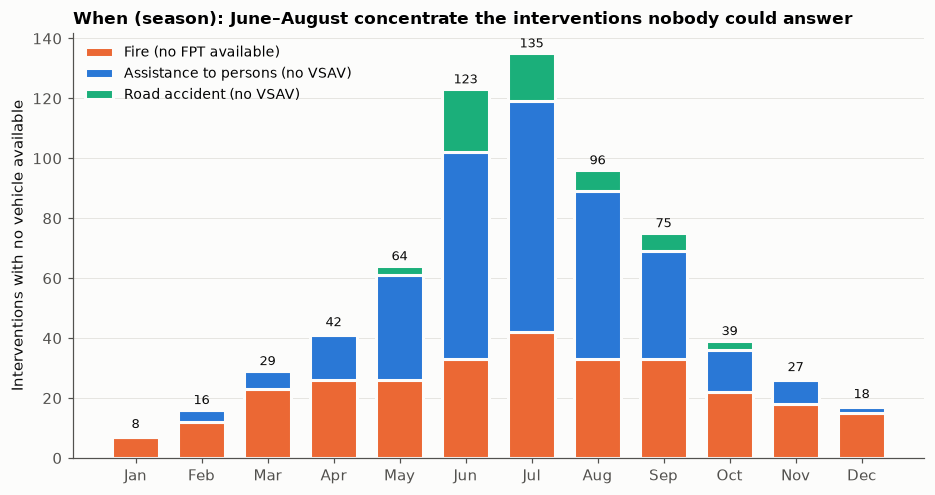

month,1,2,3,4,5,6,7,8,9,10,11,12
reason,,,,,,,,,,,,
INC,7,12,23,26,26,33,42,33,33,22,18,15
SAP,0,4,6,15,35,69,77,56,36,14,8,2
AVP,1,0,0,1,3,21,16,7,6,3,1,1


In [14]:
monthly = (interventions[interventions["unfulfilled"]]
           .assign(month=lambda d: d["alert_time"].dt.month)
           .pivot_table(index="month", columns="reason", values="id_intervention", aggfunc="count", fill_value=0)
           .reindex(range(1, 13), fill_value=0)[["INC", "SAP", "AVP"]])
labels = {"INC": "Fire (no FPT available)", "SAP": "Assistance to persons (no VSAV)", "AVP": "Road accident (no VSAV)"}

fig, ax = plt.subplots(figsize=(8.6, 4.6))
bottom = np.zeros(12)
for reason, color in zip(monthly.columns, [ORANGE, BLUE, AQUA]):
    ax.bar(monthly.index, monthly[reason], bottom=bottom, color=color, width=0.72,
           edgecolor=SURFACE, linewidth=2, label=labels[reason])
    bottom += monthly[reason].to_numpy()
for m, total in zip(monthly.index, bottom):
    ax.text(m, total + 2, f"{total:.0f}", ha="center", fontsize=8.5, color=INK)
ax.set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("Interventions with no vehicle available"); ax.grid(axis="x", visible=False)
ax.set_title("When (season): June–August concentrate the interventions nobody could answer", fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "monthly_unfulfilled.png")
plt.show()
monthly.T

## 6. Commune → first-response centre

**Rule applied: the official deployment plan.** For each commune the first centre is `plan_deploiement` rang 1.
Every centre holds a VSAV, so this centre answers first for assistance to persons and road accidents.
For fires the first engine must be an FPT, and 14 volunteer centres have none: the first FPT then comes from the
first centre of the same plan order that holds one (`first_centre_fire`).

In [15]:
table = h.first_centre_table(raw, interventions)
table.to_csv(h.RESULTS / "commune_first_centre.csv", index=False)
table.head(10)

,insee,commune,zone,first_centre,first_centre_fire,nearest_centre,observed_vsav,plan_share_vsav_pct,observed_fpt,plan_share_fpt_pct
0,25001,COM001,Z2,CIS07,CIS07,CIS07,CIS07,53.5,CIS07,66.7
1,25002,COM002,Z3,CIS29,CIS19,CIS29,CIS29,74.6,CIS19,90.0
2,25003,COM003,Z1,CIS20,CIS20,CIS20,CIS20,48.1,CIS20,74.8
3,25004,COM004,Z2,CIS01,CIS01,CIS19,CIS01,73.1,CIS01,65.9
4,25005,COM005,Z4,CIS26,CIS23,CIS26,CIS26,96.9,CIS23,75.0
5,25006,COM006,Z3,CIS24,CIS22,CIS24,CIS24,65.9,CIS22,71.4
6,25007,COM007,Z2,CIS22,CIS22,CIS22,CIS22,63.6,CIS22,62.4
7,25008,COM008,Z3,CIS09,CIS22,CIS09,CIS09,71.3,CIS22,67.7
8,25009,COM009,Z4,CIS19,CIS19,CIS29,CIS19,55.3,CIS19,63.6
9,25010,COM010,Z3,CIS14,CIS30,CIS14,CIS14,74.4,CIS30,48.1


**How the rule was checked on the data** (first-arriving vehicle of each intervention):

In [16]:
plan_ranks = raw["plan_deploiement"].set_index(["insee", "code_cis"])["rang"]
arrived = interventions.dropna(subset=["first_centre"])
used_rank = plan_ranks.reindex(pd.MultiIndex.from_arrays([arrived["insee"], arrived["first_centre"]])).to_numpy()
print("Rank (in the plan) of the centre that arrived first, % of interventions:")
print(pd.Series(used_rank).value_counts(normalize=True).sort_index().mul(100).round(1).to_dict())
print("First vehicle type by reason:", pd.crosstab(arrived["reason"], arrived["first_vehicle"]).to_dict("index"))

checks = pd.Series({
    "communes": len(table),
    "VSAV: most frequent first centre = plan rang 1": (table["observed_vsav"] == table["first_centre"]).sum(),
    "FPT: most frequent first centre = first FPT holder in plan": (table["observed_fpt"] == table["first_centre_fire"]).sum(),
    "VSAV: most frequent first centre = nearest centre": (table["observed_vsav"] == table["nearest_centre"]).sum(),
    "communes where plan rang 1 != nearest centre": (table["first_centre"] != table["nearest_centre"]).sum(),
    "communes where rang 1 holds no FPT": (table["first_centre"] != table["first_centre_fire"]).sum(),
})
checks.to_frame("count")

Rank (in the plan) of the centre that arrived first, % of interventions:
{1: 63.9, 2: 18.7, 3: 7.4, 4: 3.7, 5: 2.5, 6: 1.6, 7: 1.1, 8: 1.0}
First vehicle type by reason: {'AVP': {'FPT': 0, 'VSAV': 6471}, 'INC': {'FPT': 9684, 'VSAV': 0}, 'SAP': {'FPT': 0, 'VSAV': 38173}}


,count
communes,120
VSAV: most frequent first centre = plan rang 1,120
FPT: most frequent first centre = first FPT holder in plan,117
VSAV: most frequent first centre = nearest centre,85
communes where plan rang 1 != nearest centre,35
communes where rang 1 holds no FPT,74


In [17]:
# The few communes where the most frequent first FPT is not the plan's first FPT holder, with their number of fires
odd = table[table["observed_fpt"] != table["first_centre_fire"]]
fires = arrived[arrived["first_vehicle"] == "FPT"].groupby("insee").size().rename("fires_answered")
odd.merge(fires, left_on="insee", right_index=True)

,insee,commune,zone,first_centre,first_centre_fire,nearest_centre,observed_vsav,plan_share_vsav_pct,observed_fpt,plan_share_fpt_pct,fires_answered
26,25027,COM027,Z4,CIS29,CIS03,CIS29,CIS29,75.0,CIS19,37.5,8
43,25044,COM044,Z4,CIS28,CIS07,CIS08,CIS28,72.0,CIS23,0.0,2
68,25069,COM069,Z4,CIS11,CIS03,CIS05,CIS11,78.3,CIS20,50.0,4


Reading of the check:
- The plan's rank-1 centre arrives first in about two thirds of interventions; when it does not, the next ranks take
  over in decreasing order (2, 3, …), which is what a busy rank-1 centre produces. The plan is an ordered list
  that is actually followed.
- For VSAV, the most frequent first centre equals plan rang 1 in **all 120 communes**. The naive "nearest centre"
  rule matches only 85: the plan, not geometry, is what applies (access constraints, agreements between centres).
- Fires are always answered first by an FPT and assistance/road accidents by a VSAV. Where rang 1 holds no FPT,
  the first fire engine comes from the first FPT holder in the plan order: confirmed in 117/120 communes; the 3
  exceptions are isolated Z4 communes with only 2–8 fires in the year, too few to contradict the plan.
- Limit: the data has no vehicle return times, so "all resources available" cannot be isolated exactly; the most
  frequent first centre is used as its proxy.

## 7. Task 1 — summary

- **Indicators:** P90 SAP 25.51 min and 290 unfulfilled fires reproduced exactly; compliance 86.46 % vs 86.45 %
  (sub-second rounding of 7 interventions on their threshold, explained in section 4).
- **Where:** late arrivals are a geographic problem first — communes covered by a volunteer centre are on time
  ~65 % of the time against ~95 % for professional ones, worst in outlying Z3 communes.
- **When:** punctuality drops during the daytime peak of calls (≈ 12h–20h), and unfulfilled interventions —
  mostly fires — concentrate in June–August.
- **Commune table:** `results/commune_first_centre.csv`, built from the official plan and confirmed on the data
  (plan rang 1 for VSAV in 120/120 communes; first FPT holder for fires).